In [ ]:
!pip install pandas numpy scikit-learn tensorflow scikeras matplotlib

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, precision_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# !pip uninstall -y scikit-learn
# !pip install scikit-learn==1.5.2

In [4]:
# !sudo apt-get install python3.10
# !sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1
# !python --version

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Melhores parâmetros:
{'activation': 'tanh', 'hidden_layer_sizes': [32, 32], 'kernel_initializer': 'glorot_uniform'}
Melhor acurácia: 0.8776

Métricas no Treino:


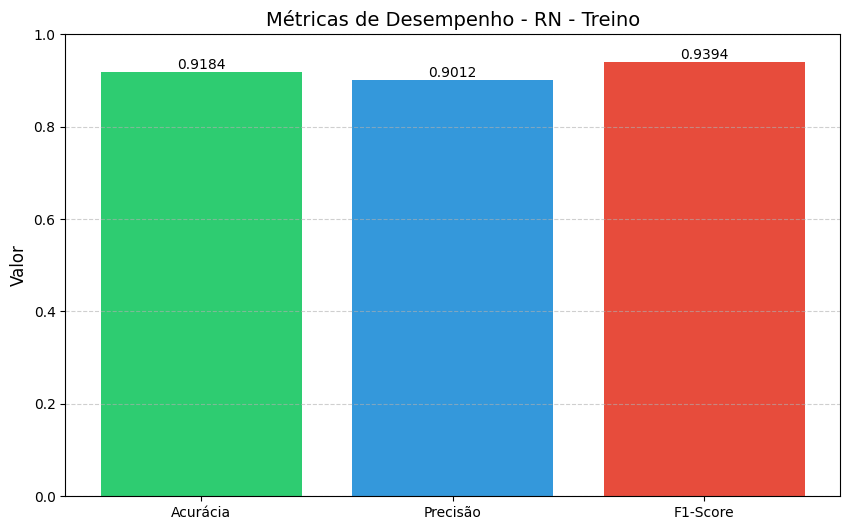


Métricas no Teste:


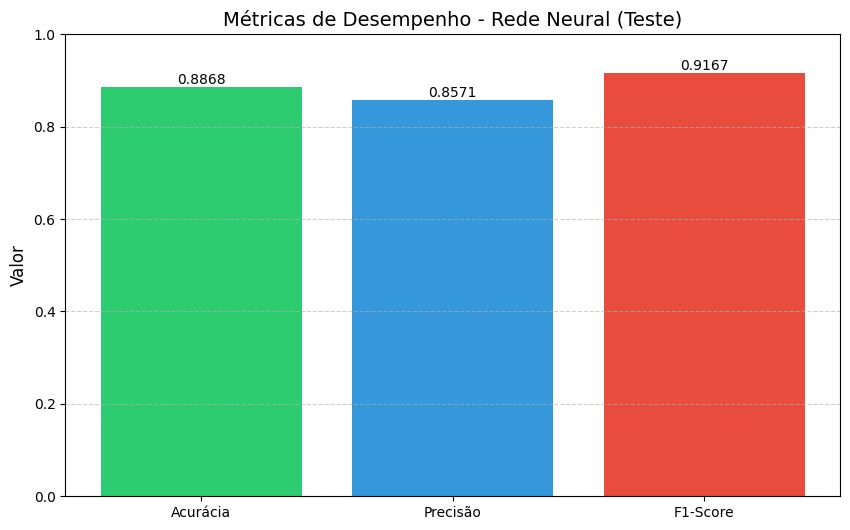


Métricas de classificação:
              precision    recall  f1-score   support

           0       0.97      0.72      0.82        39
           1       0.86      0.99      0.92        67

    accuracy                           0.89       106
   macro avg       0.91      0.85      0.87       106
weighted avg       0.90      0.89      0.88       106



In [14]:
def load_and_preprocess_data():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
    columns = [f'feature_{i}' for i in range(34)] + ['target']
    data = pd.read_csv(url, names=columns)

    #cdificação dos rótulos (g -> 1, b -> 0)
    data['target'] = (data['target'] == 'g').astype(int)

    X = data.drop('target', axis=1)
    y = data['target']

    #divisão dos dados de treinamento - treino (70%) e teste (30%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    #normalização
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

def create_model(hidden_layer_sizes=[32], activation='relu', kernel_initializer='glorot_uniform'):
    model = Sequential()
    #primeira camada
    model.add(Dense(
        hidden_layer_sizes[0],
        input_dim=34,
        activation=activation,
        kernel_initializer=kernel_initializer
    ))
    #camadas escondidas adicionais
    for neurons in hidden_layer_sizes[1:]:
        model.add(Dense(
            neurons,
            activation=activation,
            kernel_initializer=kernel_initializer
        ))
    #camada de saída
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

def perform_grid_search(X_train, y_train):
    model = KerasClassifier(
        model=create_model,
        hidden_layer_sizes=[32],
        activation='relu',
        kernel_initializer='glorot_uniform',
        epochs=10,
        batch_size=32,
        verbose=0
    )

    param_grid = {
        'hidden_layer_sizes': [[32], [64], [32, 32], [64, 32]],
        'activation': ['relu', 'tanh'],
        'kernel_initializer': ['glorot_uniform', 'random_uniform']
    }

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    return grid_search

def plot_metrics(y_true, y_pred, model_name):
    metrics = {
        'Acurácia': accuracy_score(y_true, y_pred),
        'Precisão': precision_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

    plt.figure(figsize=(10, 6))
    bars = plt.bar(metrics.keys(), metrics.values(), color=['#2ecc71', '#3498db', '#e74c3c'])

    plt.title(f'Métricas de Desempenho - {model_name}', fontsize=14)
    plt.ylabel('Valor', fontsize=12)
    plt.ylim(0.0, 1.0)

    #adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}', ha='center', va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

def main():
    X_train, X_test, y_train, y_test = load_and_preprocess_data()
    grid_search = perform_grid_search(X_train, y_train)

    print("\nMelhores parâmetros:")
    print(grid_search.best_params_)
    print(f"Melhor acurácia: {grid_search.best_score_:.4f}")

    best_model = grid_search.best_estimator_

    #previsões
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    #gráficos de métricas
    print("\nMétricas no Treino:")
    plot_metrics(y_train, y_train_pred, "RN - Treino")

    print("\nMétricas no Teste:")
    plot_metrics(y_test, y_test_pred, "Rede Neural (Teste)")

    # Relatório detalhado
    print("\nMétricas de classificação:")
    print(classification_report(y_test, y_test_pred))

if __name__ == "__main__":
    main()